<a href="https://colab.research.google.com/github/AkiraGabriel/Enem-2019/blob/main/Enem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Olympiad - QUALITY EDUCATION

ML Olympiad – Previsão das notas da prova do ENEM ([Link](https://www.kaggle.com/competitions/qualityeducation/data))

[Dicionário de dados](https://docs.google.com/spreadsheets/d/14C4lbQFEmUnIJN17gr01L8ikXsT27eHZ/edit?usp=sharing&ouid=101143319330377699057&rtpof=true&sd=true) (significado das colunas)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from IPython.display import display, Markdown
import re
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
BASEDIR = Path('..') / 'data'
df = pd.read_csv(BASEDIR / 'train.csv', nrows=5000)

NameError: name 'Path' is not defined

## Dicionário de dados

In [1]:
dicionario = pd.read_excel('Dicionario_Microdados_Enem.xlsx', skiprows=2)
display(Markdown(dicionario.to_markdown(index=False)))

NameError: name 'pd' is not defined

In [14]:
descriptions = dicionario[['NOME DA VARIÁVEL',	'Descrição']].copy().dropna().set_index('NOME DA VARIÁVEL')

In [15]:
dicionario_nacionalidade = {
    '0': "Nãp declarados"    ,
    '1': "Brancos"    ,
    '2': "Pretos"   ,
    '3': "Pardos"    ,
    '4': "Amarelos"    ,
    '5': "Indígenas"    ,
}

df['TP_COR_RACA'] = df.TP_COR_RACA.replace(dicionario_nacionalidade)

In [16]:
dicionario['prim2'] = dicionario['NOME DA VARIÁVEL'].str.slice(0,2)
dicionario['prim2'].dropna().unique()

<StringArray>
['DA', 'NU', 'CO', 'NO', 'SG', 'TP', 'IN', 'Q0', '1.', '2.', '3.', '4.', '5.']
Length: 13, dtype: str

In [17]:
dicionario['prim2']

0      NaN
1       DA
2       NU
3       CO
4      NaN
      ... 
373     1.
374     2.
375     3.
376     4.
377     5.
Name: prim2, Length: 378, dtype: str

In [18]:
dict_renda = {
    'A': "Nenhuma renda"    ,
    'B': "Até R$ 998,00"    ,
    'C': "De R$ 998,01 até R$ 1.497,00"   ,
    'D': "De R$ 1.497,01 até R$ 1.996,00."    ,
    'E': "De R$ 1.996,01 até R$ 2.495,00."    ,
    'F': "De R$ 2.495,01 até R$ 2.994,00."    ,
    'G': "De R$ 2.994,01 até R$ 3.992,00."    ,
    'H': "De R$ 3.992,01 até R$ 4.990,00."    ,
    'I': "De R$ 4.990,01 até R$ 5.988,00."    ,
    'J': "De R$ 5.988,01 até R$ 6.986,00."    ,
    'K': "De R$ 6.986,01 até R$ 7.984,00."    ,
    'L': "De R$ 7.984,01 até R$ 8.982,00."    ,
    'M': "De R$ 8.982,01 até R$ 9.980,00."    ,
    'N': "De R$ 9.980,01 até R$ 11.976,00."   ,
    'O': "De R$ 11.976,01 até R$ 14.970,00."   ,
    'P': "De R$ 14.970,01 até R$ 19.960,00."   ,
    'Q': "Mais de R$ 19.960,00."
}
df['renda_familiar'] = df['Q006'].replace(dict_renda)
df['renda_familiar']

0       De R$ 1.996,01 até R$ 2.495,00.
1       De R$ 1.996,01 até R$ 2.495,00.
2       De R$ 2.495,01 até R$ 2.994,00.
3                         Até R$ 998,00
4       De R$ 7.984,01 até R$ 8.982,00.
                     ...               
4995                      Até R$ 998,00
4996    De R$ 1.996,01 até R$ 2.495,00.
4997                      Até R$ 998,00
4998                      Até R$ 998,00
4999    De R$ 2.994,01 até R$ 3.992,00.
Name: renda_familiar, Length: 5000, dtype: str

In [19]:
df.head()

,NU_INSCRICAO,CO_MUNICIPIO_RESIDENCIA,NO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,SG_UF_RESIDENCIA,NU_IDADE,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,...,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,renda_familiar
0,d7e73c5f-2db8-4089-9bee-d3a0e045f87f,1100023,Ariquemes,11,RO,31.0,F,0,1,1,...,A,A,B,A,A,C,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
1,668bf6e4-ddf7-4810-b31e-7d325e36de4d,3106200,Belo Horizonte,31,MG,23.0,F,1,3,1,...,A,A,B,A,A,C,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
2,951e80d6-ac9b-4ff2-8130-fcbc8ac78b16,3139409,Manhuaçu,31,MG,17.0,M,0,3,1,...,A,B,C,B,B,D,A,B,B,"De R$ 2.495,01 até R$ 2.994,00."
3,baf409f9-ddc6-4e82-9a4b-b64b579cd105,2506301,Guarabira,25,PB,16.0,M,1,1,1,...,A,A,B,A,A,E,A,A,B,"Até R$ 998,00"
4,9fd415ac-3421-44ce-810e-599545c3c025,2304400,Fortaleza,23,CE,19.0,M,1,1,1,...,A,A,E,B,B,C,B,B,B,"De R$ 7.984,01 até R$ 8.982,00."


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 119 entries, NU_INSCRICAO to renda_familiar
dtypes: float64(16), int64(68), str(35)
memory usage: 4.5 MB


In [21]:
df.isnull().sum()

NU_INSCRICAO               0
CO_MUNICIPIO_RESIDENCIA    0
NO_MUNICIPIO_RESIDENCIA    0
CO_UF_RESIDENCIA           0
SG_UF_RESIDENCIA           0
                          ..
Q022                       0
Q023                       0
Q024                       0
Q025                       0
renda_familiar             0
Length: 119, dtype: int64

In [22]:
df.dropna()

,NU_INSCRICAO,CO_MUNICIPIO_RESIDENCIA,NO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,SG_UF_RESIDENCIA,NU_IDADE,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,...,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,renda_familiar
2,951e80d6-ac9b-4ff2-8130-fcbc8ac78b16,3139409,Manhuaçu,31,MG,17.0,M,0,3,1,...,A,B,C,B,B,D,A,B,B,"De R$ 2.495,01 até R$ 2.994,00."
6,cf31ebe2-85d0-4e10-be47-0ea9f49f9242,2111607,São Raimundo das Mangabeiras,21,MA,17.0,F,1,3,1,...,A,A,B,B,A,A,A,A,A,"Até R$ 998,00"
7,e27bdbb9-e320-476a-ba73-1cdd211c436d,3132404,Itajubá,31,MG,18.0,F,1,1,1,...,A,A,B,A,B,C,A,A,B,"De R$ 2.994,01 até R$ 3.992,00."
10,e054769b-4932-4df9-bc8e-bd65538a67fb,2408102,Natal,24,RN,19.0,M,1,3,1,...,A,B,C,A,B,E,A,E,B,"De R$ 5.988,01 até R$ 6.986,00."
14,dbd76c6e-2eb0-461a-a13f-4800ad0ea7a5,3502903,Araçoiaba da Serra,35,SP,17.0,F,1,1,1,...,A,B,B,B,A,E,A,B,B,"De R$ 2.994,01 até R$ 3.992,00."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4987,5945d551-fc4e-44f7-9f86-06d4077a6c61,2311702,Reriutaba,23,CE,19.0,F,1,3,1,...,A,A,B,A,A,D,A,A,A,"Até R$ 998,00"
4989,ece17ba2-7150-48e9-9c45-4c66f3bdf96a,1600600,Santana,16,AP,18.0,M,1,1,1,...,A,A,B,A,A,D,A,B,B,"De R$ 1.996,01 até R$ 2.495,00."
4992,337fa1b9-b011-4237-87fc-17b5d1326e20,2601102,Araripina,26,PE,19.0,M,1,3,1,...,A,A,B,B,A,C,A,A,B,"De R$ 998,01 até R$ 1.497,00"
4993,d43be82b-42cf-4a5b-a6d6-ab71f5643e62,2200400,Altos,22,PI,19.0,F,1,3,1,...,A,A,B,B,B,E,A,B,B,"De R$ 1.497,01 até R$ 1.996,00."


### Excluimos inscritos sem nota média

In [23]:
df = df.dropna()

In [24]:
df['nota_Media'] = ((df['NU_NOTA_CN'] + df['NU_NOTA_CH'] + df['NU_NOTA_LC'] + df['NU_NOTA_MT']) / 4)

In [25]:
df['nota_Media']

2       502.375
6       411.200
7       520.325
10      543.700
14      526.125
         ...   
4987    447.850
4989    579.525
4992    549.850
4993    402.800
4996    454.950
Name: nota_Media, Length: 881, dtype: float64

In [26]:
df['Q001'].value_counts(sort=False)

Q001
E    271
D    114
G     57
H     94
C    138
B    120
A     22
F     65
Name: count, dtype: int64

/tmp/ipykernel_159228/1923377384.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= df["TP_SEXO"].map({"F": "Mulheres", "M": "Homens"}),


Text(0.5, 0, 'Sexo')

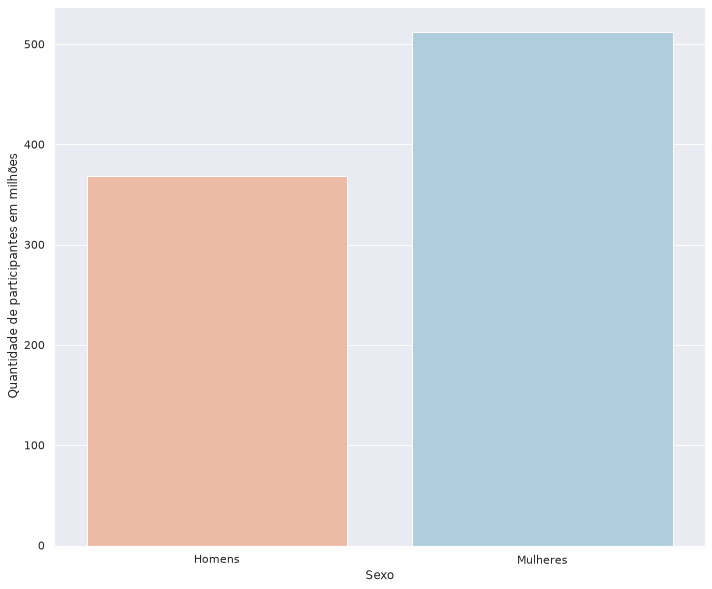

In [27]:
sns.set_theme(
    style='darkgrid',
    # palette='dark',
    rc = {
        'legend.loc': 'upper right',
    }
)
fig, ax = plt.subplots(dpi=70, figsize=(12, 10))

sns.countplot(data=df, x= df["TP_SEXO"].map({"F": "Mulheres", "M": "Homens"}),
             palette="RdBu", ax=ax)

for c in ax.containers:
    for v in c:
        bar_height = v.get_height()
        x_value = v.get_x()
        text = "{:.1%}".format(bar_height/len(df))
ax.set_ylabel("Quantidade de participantes em milhões")
ax.set_xlabel("Sexo")

### Nota média por fatores sociais

In [ ]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('Q')]):
    counts = df[column].value_counts().sort_values(ascending=False)
    sns.barplot(x=counts.index, y=counts, ax=ax)
    ax.set_ylabel('Contagem')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, count=0, flags=re.DOTALL)
    ax.set_title(title)

### Nota média por sexo, estado civil, raça e etc

In [ ]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(4,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('TP')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('NU_NOTA')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Nota média')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, count=0, flags=re.DOTALL)
    ax.set_title(title)

### Nota média de treineiro e portadores de condições especiais

In [ ]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('IN')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('NU_NOTA')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Nota média')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, count=0, flags=re.DOTALL)
    ax.set_title(title)

### Presença por Condições especiais

In [ ]:
fig = plt.figure(figsize=(50,50))
axs = fig.subplots(5,5)
for ax, column in zip(axs.flat, df.columns[df.columns.str.startswith('IN')]):
    grades = df[[column, *df.columns[df.columns.str.startswith('TP_PRESENCA_CN')]]].groupby(column).mean().mean(axis=1)
    sns.barplot(x=grades.index, y=grades, ax=ax)
    ax.set_ylabel('Presença')
    title = descriptions.loc[column, 'Descrição']
    title = re.sub("(.{75})", "\\1\n", title, count=0, flags=re.DOTALL)
    ax.set_title(title)

<Axes: xlabel='NU_IDADE', ylabel='nota_Media'>

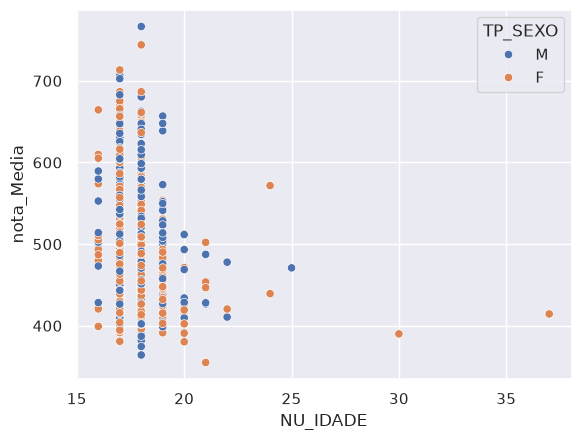

In [32]:
sns.scatterplot(data=df, x="NU_IDADE", y="nota_Media", hue='TP_SEXO')

# TODO

* Plotar relação entre notas e colunas de escola (TP) - Feito
* Ver se os INs relevante a prova (tempo extra por PCD, etc.) não tem relação com a nota - Feito
* Talvez ver se relaçã entre características da pessoa e faltar (mas pensar se não é coincidência porque pode ser) - Feito
* Talvez tirar as pessoas que nao tem presença em alguam prova antes de treinar - Feito
* Plotar nota por prova por questao que começa com Q (gráfico de barras) - Feito

## Modelo de regressão

### EDA

In [33]:
nota_E = df[(df['nota_Media'] > 0) & (df['nota_Media'] <= 200)]
nota_D = df[(df['nota_Media'] > 200) & (df['nota_Media'] <= 400)]
nota_C = df[(df['nota_Media'] > 400) & (df['nota_Media'] <= 600)]
nota_B = df[(df['nota_Media'] > 600) & (df['nota_Media'] <= 800)]
nota_A = df[(df['nota_Media'] > 800) & (df['nota_Media'] <= 1000)]

Text(0.5, 1.0, 'Idade dos participantes do ENEM 2019')

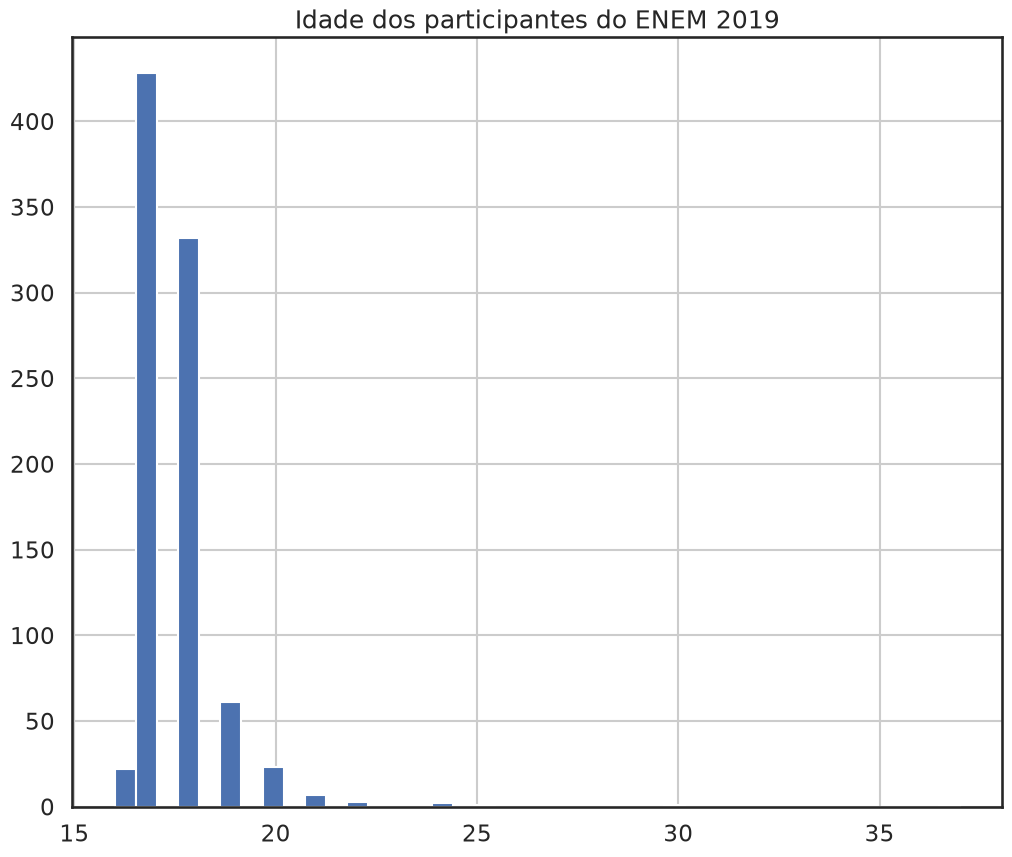

In [34]:
sns.set_theme(style="white", context="talk")
df["NU_IDADE"].hist(bins = 40, figsize = (12,10)).set_title("Idade dos participantes do ENEM 2019")

Text(0.5, 0, 'Etnia')

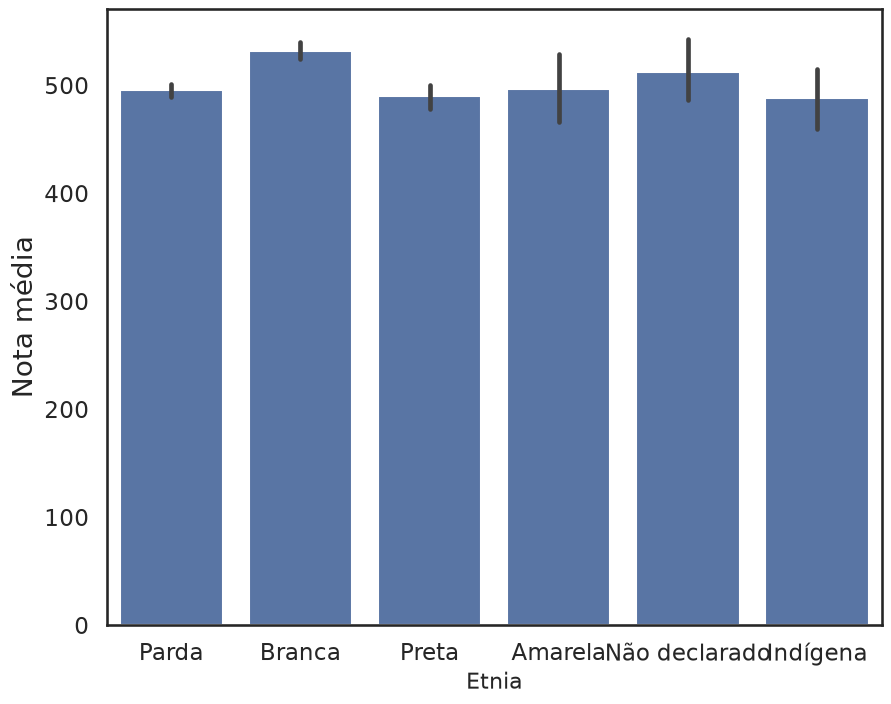

In [35]:
plt.rcParams['figure.figsize'] = (10, 8)
sns.barplot(data=df,
            x = df['TP_COR_RACA'].map({0:'Não declarado',1:'Branca',2:'Preta',3:'Parda',4:'Amarela',5:'Indígena'}), y = df['nota_Media']);
plt.ylabel('Nota média', fontsize=20)
plt.xlabel('Etnia', fontsize=16)

Text(0.5, 0, 'Modalidade')

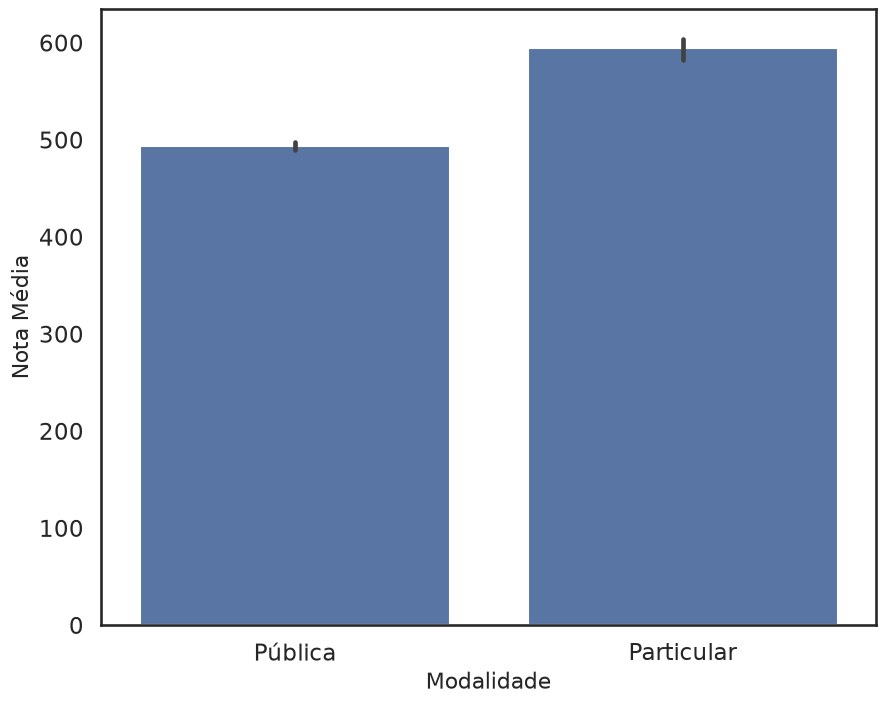

In [36]:
sns.barplot(data=df, x = df['TP_ESCOLA'].map({1:'Não respondeu',2:'Pública',3:'Particular'}), y = df['nota_Media'])
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Modalidade', fontsize=16)

/home/gakira/Programming/Python/Enem-2019/enem/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


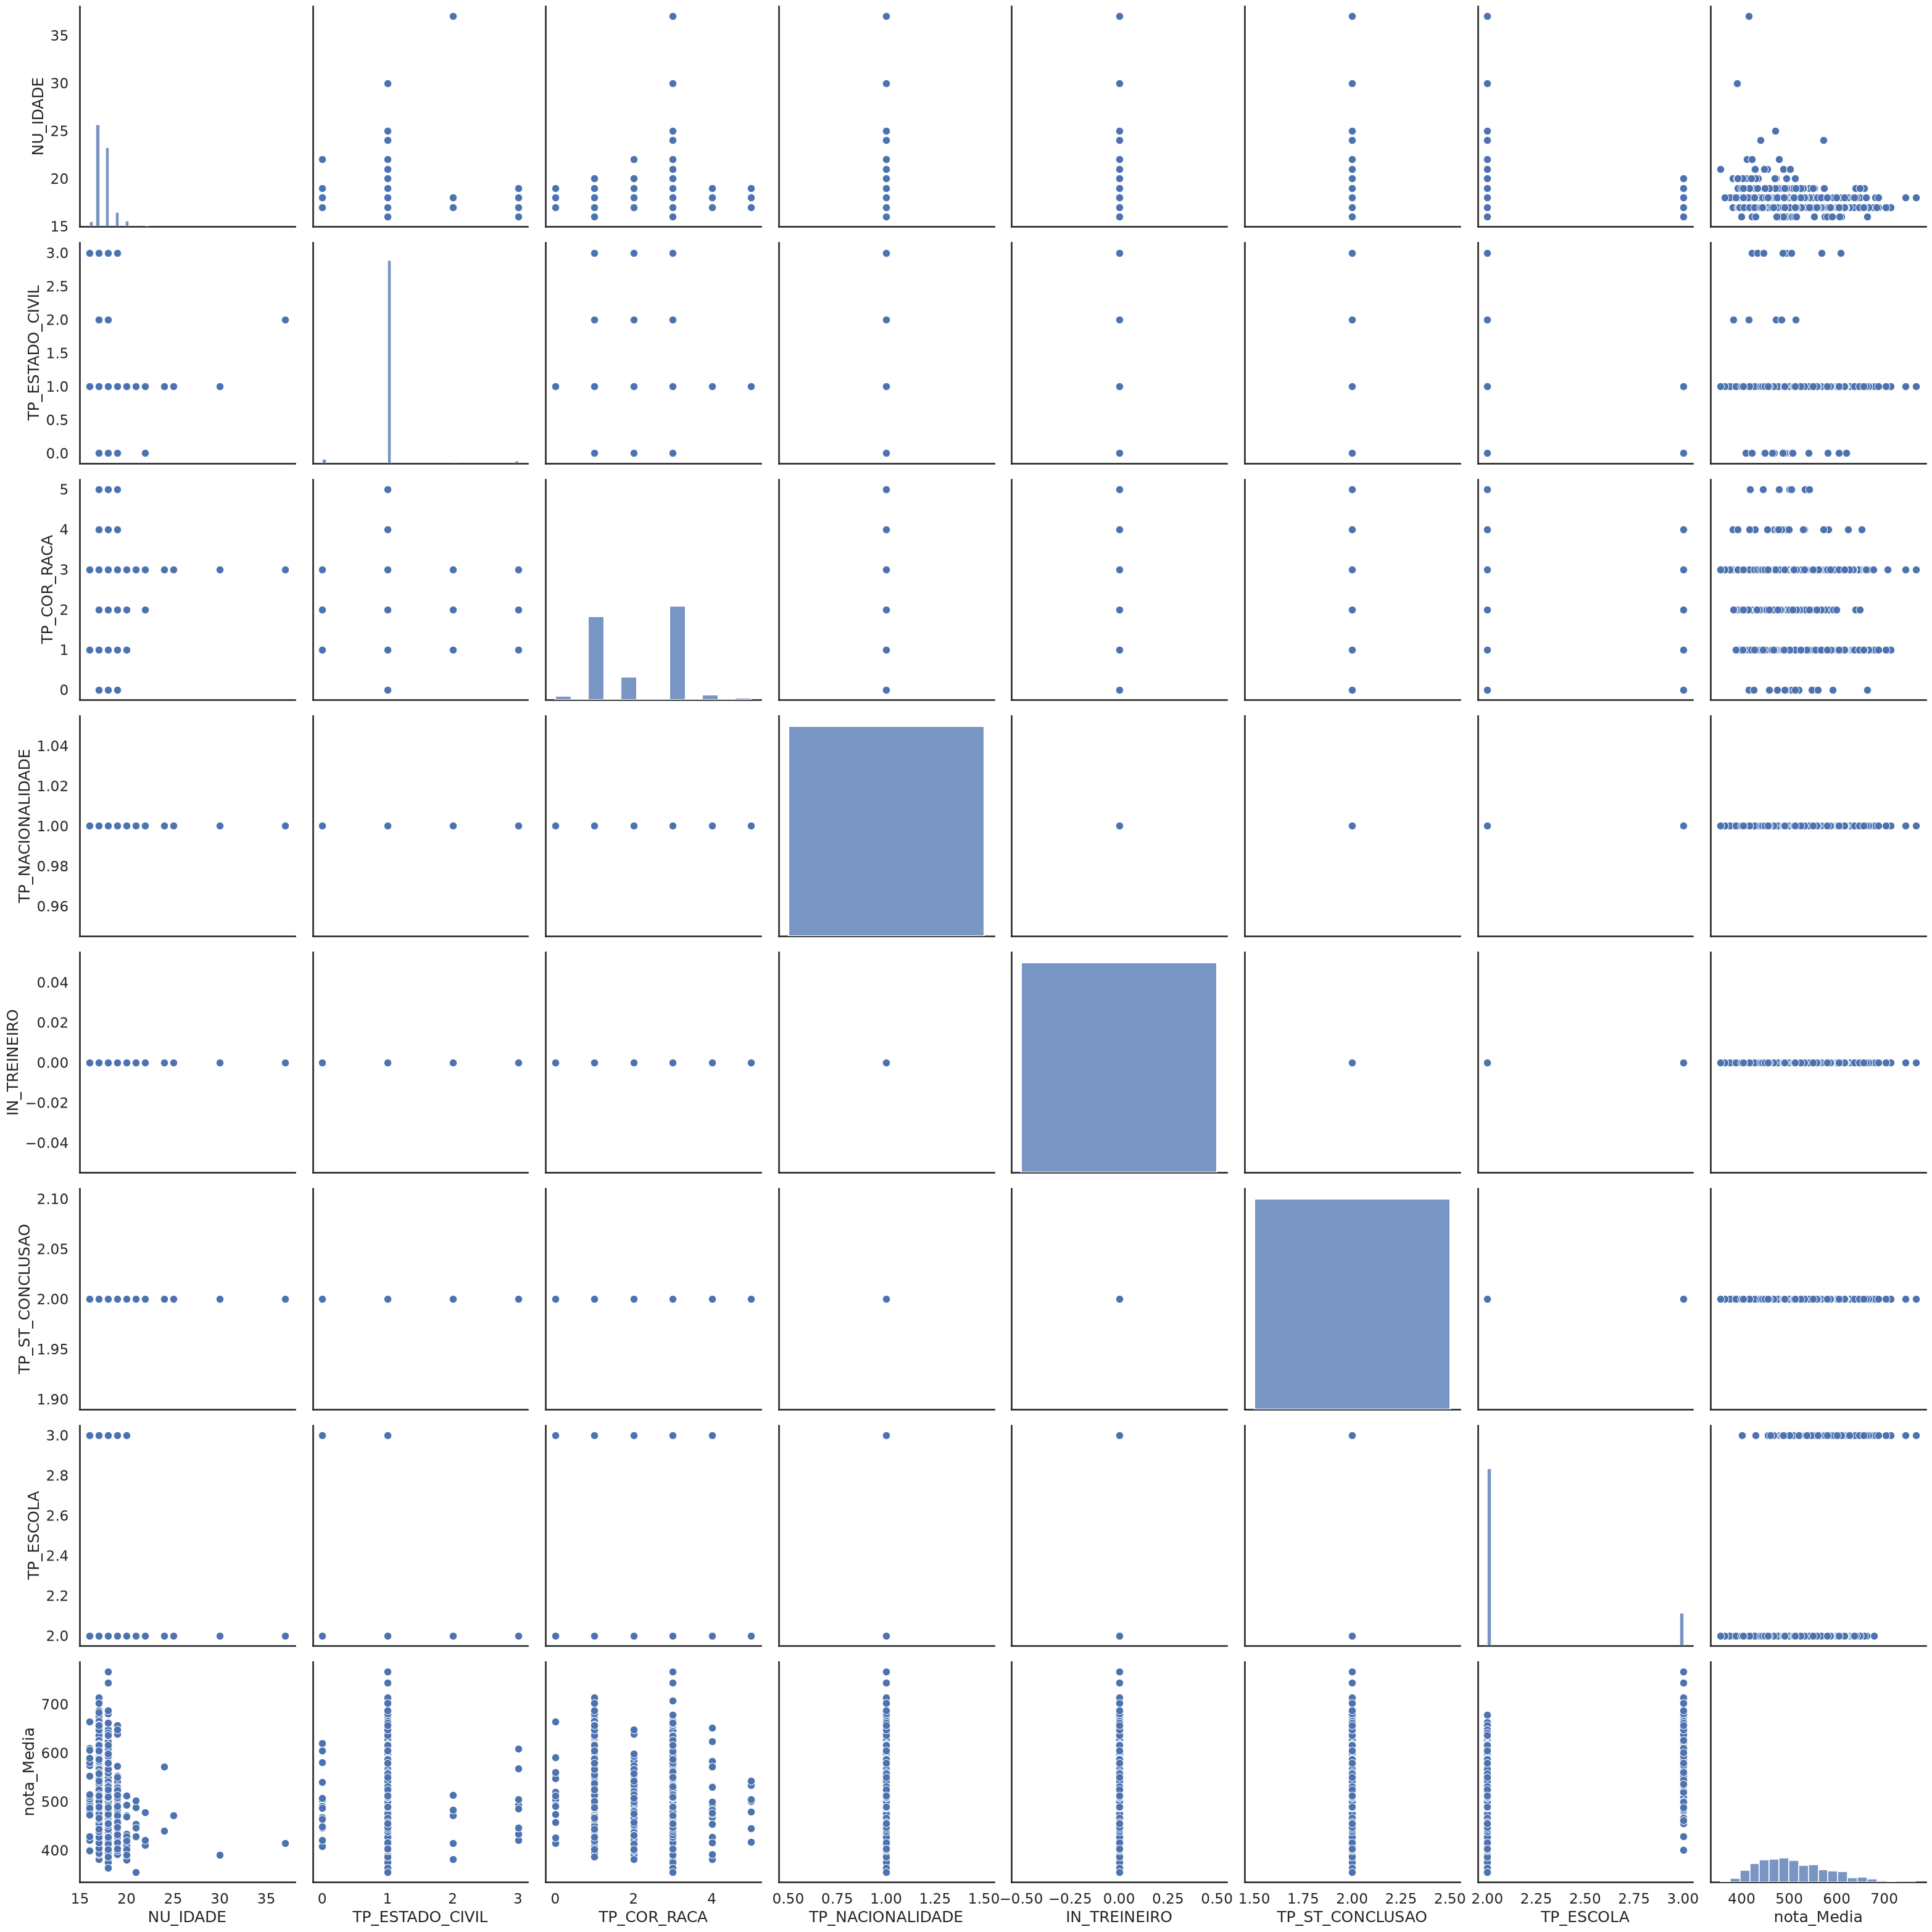

In [37]:
sns.pairplot(data = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'nota_Media']], size=4,diag_kind="hist")

Text(0.5, 0, 'Idade')

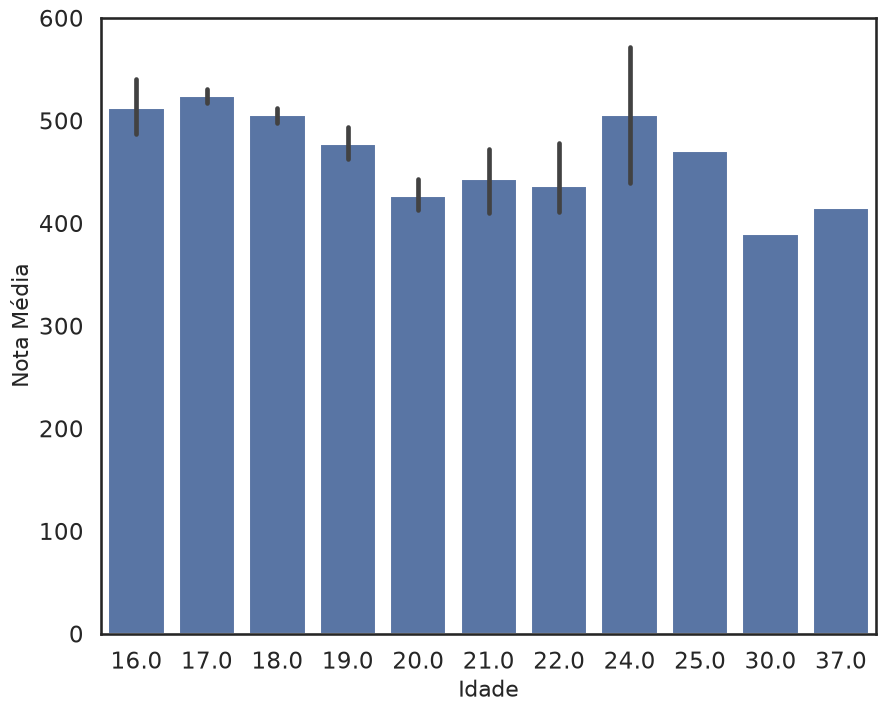

In [38]:
sns.barplot(data=df, x = 'NU_IDADE', y = 'nota_Media')
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Idade', fontsize=16)

Text(0.5, 0, 'Estado Civil')

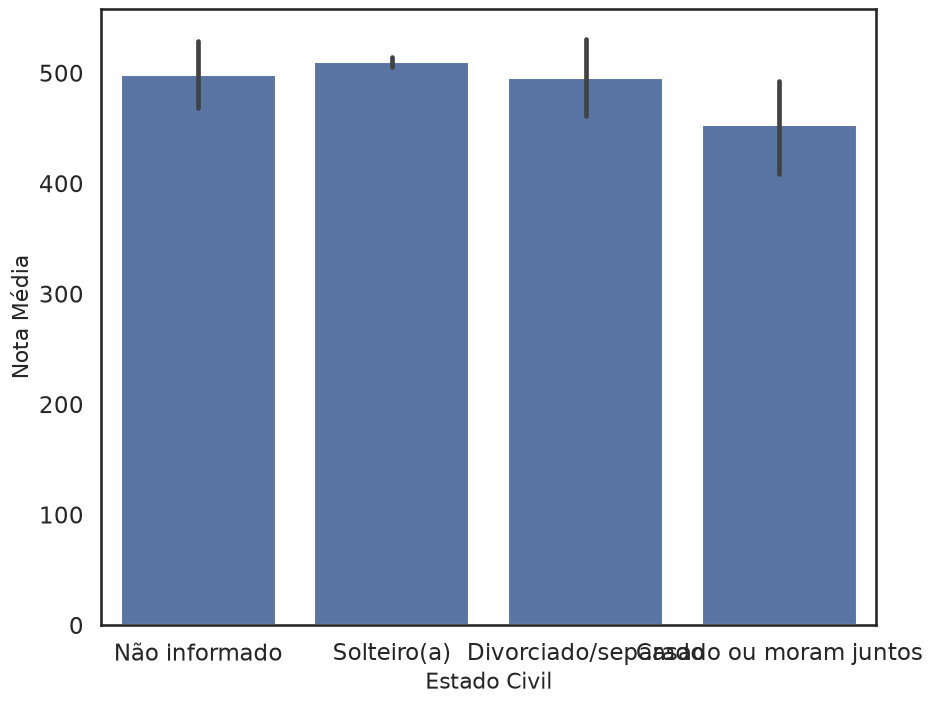

In [39]:
sns.barplot(data=df, x = df['TP_ESTADO_CIVIL'].map({0:'Não informado', 1:'Solteiro(a)', 2:'Casado ou moram juntos', 3:'Divorciado/separado'}), y = 'nota_Media')
plt.ylabel('Nota Média', fontsize=16)
plt.xlabel('Estado Civil', fontsize=16)

Text(0, 0.5, 'Nota Média')

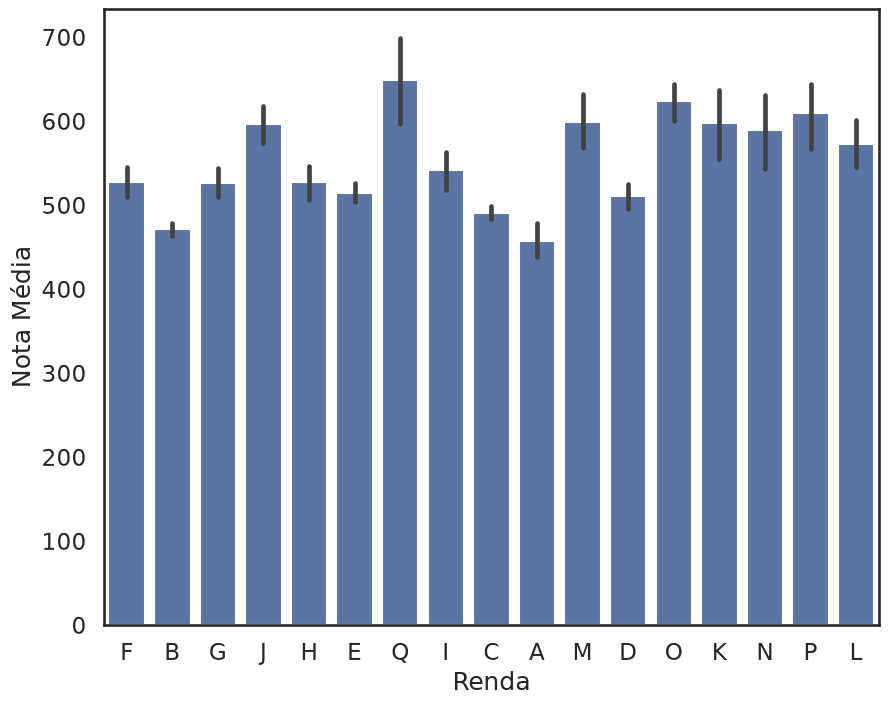

In [40]:
sns.barplot(data=df, x= 'Q006', y = 'nota_Media')
plt.xlabel('Renda')
plt.ylabel('Nota Média')

### Fazer só com as colunas numéricas

In [41]:
### Fazer isso só com as colunas numéricas
#sns.pairplot(dados.iloc[:, :10])

In [42]:
#plt.figure(figsize=(50, 50))
#sns.heatmap(dados.corr(''), annot=True, fmt='.0%')
#IN_SEM_RECURSO

In [43]:
#plt.figure(figsize=(50, 50))
#sns.heatmap(dados.corr(), annot=True, fmt='.0%')

In [44]:
"""
Como treinar qualquer modelo:

Iniciante:
* Train test split (se ja nao foi separado, nesse caso nao precisa)
* Treino com o dataset de treino
* Gera as predições com conjunto de teste (x)
* Calcula erros: RMSE, MAE, R2, etc.
* Compara os resultados, testa usar menos ou mais variáveis, etc.
* Começa so com as numéricas

Intermediário:
* Train test split (se ja nao foi separado, nesse caso nao precisa)
* Validação cruzada com k fold
* Gera as predições com o conjunto de teste (x)
* Calcula erros: RMSE, MAE, R2, etc.
* Compara os resultados de validação e treino


Repete o passo para varios modelos. Recomendado: LinearRegession para começar, LinearRegression com algumas variáveis criadas multiplicando, tirando raiz quadrada, polinômio, etc. de variáveis que existe (vc escolhe a função vendo qual tem a maior correlação com o y)
Depois se quiser pode usar Ridge, Lasso, ElasticNet, SVR, e fazer tuning de parâmetros 

Faz um passo para cada nota do enem
"""

'\nComo treinar qualquer modelo:\n\nIniciante:\n* Train test split (se ja nao foi separado, nesse caso nao precisa)\n* Treino com o dataset de treino\n* Gera as predições com conjunto de teste (x)\n* Calcula erros: RMSE, MAE, R2, etc.\n* Compara os resultados, testa usar menos ou mais variáveis, etc.\n* Começa so com as numéricas\n\nIntermediário:\n* Train test split (se ja nao foi separado, nesse caso nao precisa)\n* Validação cruzada com k fold\n* Gera as predições com o conjunto de teste (x)\n* Calcula erros: RMSE, MAE, R2, etc.\n* Compara os resultados de validação e treino\n\n\nRepete o passo para varios modelos. Recomendado: LinearRegession para começar, LinearRegression com algumas variáveis criadas multiplicando, tirando raiz quadrada, polinômio, etc. de variáveis que existe (vc escolhe a função vendo qual tem a maior correlação com o y)\nDepois se quiser pode usar Ridge, Lasso, ElasticNet, SVR, e fazer tuning de parâmetros \n\nFaz um passo para cada nota do enem\n'

# Treino Modelo 1

In [45]:
train_size = int(len(df)*0.6)
X = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']]
Y = df['nota_Media']

In [46]:
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.30, random_state=42)

In [47]:
reg = LinearRegression()
modelo1 = reg.fit(X_train, y_train)
y_pred = modelo1.predict(X_test)
reg.coef_

array([-9.09185244,  1.39490969, -7.32158963,  0.        ,  0.        ,
       94.41694562])

Cálculo de erros

In [48]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

3586.6449152020446

In [49]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

48.67858810051791

In [50]:
#R2 Score
r2 = r2_score(y_test, y_pred)
r2

0.2481137277921991

# Treino Modelo 2

In [51]:
train_size = int(len(df)*0.6)
X = df[['NU_IDADE', 'TP_COR_RACA', 'TP_ST_CONCLUSAO', 'TP_ESCOLA']]
Y = df['nota_Media']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.40, random_state=13)

In [53]:
reg = LinearRegression()
modelo2 = reg.fit(X_train, y_train)
y_pred = modelo2.predict(X_test)
reg.coef_

array([-14.68245536,  -4.58720312,   0.        ,  97.78214261])

Cálculo de erros

In [54]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

3486.0986562239536

In [55]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

47.03898755100987

In [56]:
#R2 Score
r2 = r2_score(y_test, y_pred)
r2

0.2649240623105841

# Treino Modelo 3

In [57]:
train_size = int(len(df)*0.6)
#Q006
X = df[['NU_IDADE', 'TP_COR_RACA', 'IN_TREINEIRO']]
Y = df['nota_Media']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=22)

In [59]:
reg = LinearRegression()
modelo3 = reg.fit(X_train, y_train)
y_pred = modelo3.predict(X_test)
reg.coef_

array([-16.87409391, -14.23593302,   0.        ])

Cálculo de erros

In [60]:
#Erro quadrado
mean_squared_error(y_test, y_pred)

4776.440221350757

In [61]:
#Erro absoluto
mean_absolute_error(y_test, y_pred)

56.841925603263654

In [62]:
#R2
r2 = r2_score(y_test, y_pred)
r2

0.06840064907833121

## Análise Exploratória de Dados

In [63]:
#?pd.DataFrame.describe
df.describe

<bound method NDFrame.describe of                               NU_INSCRICAO  CO_MUNICIPIO_RESIDENCIA  \
2     951e80d6-ac9b-4ff2-8130-fcbc8ac78b16                  3139409   
6     cf31ebe2-85d0-4e10-be47-0ea9f49f9242                  2111607   
7     e27bdbb9-e320-476a-ba73-1cdd211c436d                  3132404   
10    e054769b-4932-4df9-bc8e-bd65538a67fb                  2408102   
14    dbd76c6e-2eb0-461a-a13f-4800ad0ea7a5                  3502903   
...                                    ...                      ...   
4987  5945d551-fc4e-44f7-9f86-06d4077a6c61                  2311702   
4989  ece17ba2-7150-48e9-9c45-4c66f3bdf96a                  1600600   
4992  337fa1b9-b011-4237-87fc-17b5d1326e20                  2601102   
4993  d43be82b-42cf-4a5b-a6d6-ab71f5643e62                  2200400   
4996  26b84785-8ac7-4ccd-b7f6-a6dadc10ee56                  3167202   

           NO_MUNICIPIO_RESIDENCIA  CO_UF_RESIDENCIA SG_UF_RESIDENCIA  \
2                         Manhuaçu      

In [64]:
df.info

<bound method DataFrame.info of                               NU_INSCRICAO  CO_MUNICIPIO_RESIDENCIA  \
2     951e80d6-ac9b-4ff2-8130-fcbc8ac78b16                  3139409   
6     cf31ebe2-85d0-4e10-be47-0ea9f49f9242                  2111607   
7     e27bdbb9-e320-476a-ba73-1cdd211c436d                  3132404   
10    e054769b-4932-4df9-bc8e-bd65538a67fb                  2408102   
14    dbd76c6e-2eb0-461a-a13f-4800ad0ea7a5                  3502903   
...                                    ...                      ...   
4987  5945d551-fc4e-44f7-9f86-06d4077a6c61                  2311702   
4989  ece17ba2-7150-48e9-9c45-4c66f3bdf96a                  1600600   
4992  337fa1b9-b011-4237-87fc-17b5d1326e20                  2601102   
4993  d43be82b-42cf-4a5b-a6d6-ab71f5643e62                  2200400   
4996  26b84785-8ac7-4ccd-b7f6-a6dadc10ee56                  3167202   

           NO_MUNICIPIO_RESIDENCIA  CO_UF_RESIDENCIA SG_UF_RESIDENCIA  \
2                         Manhuaçu        

In [65]:
col_selecionadas = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ANO_CONCLUIU','IN_TREINEIRO', 'Q006', 'TP_ESCOLA', 'TP_ESTADO_CIVIL', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'IN_DEFICIT_ATENCAO', 'nota_Media']]
corr_matrix=col_selecionadas.corr()
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(corr_matrix, cmap='PuOr')

ValueError: could not convert string to float: 'F'

/usr/local/lib/python3.7/dist-packages/seaborn/axisgrid.py:2076: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


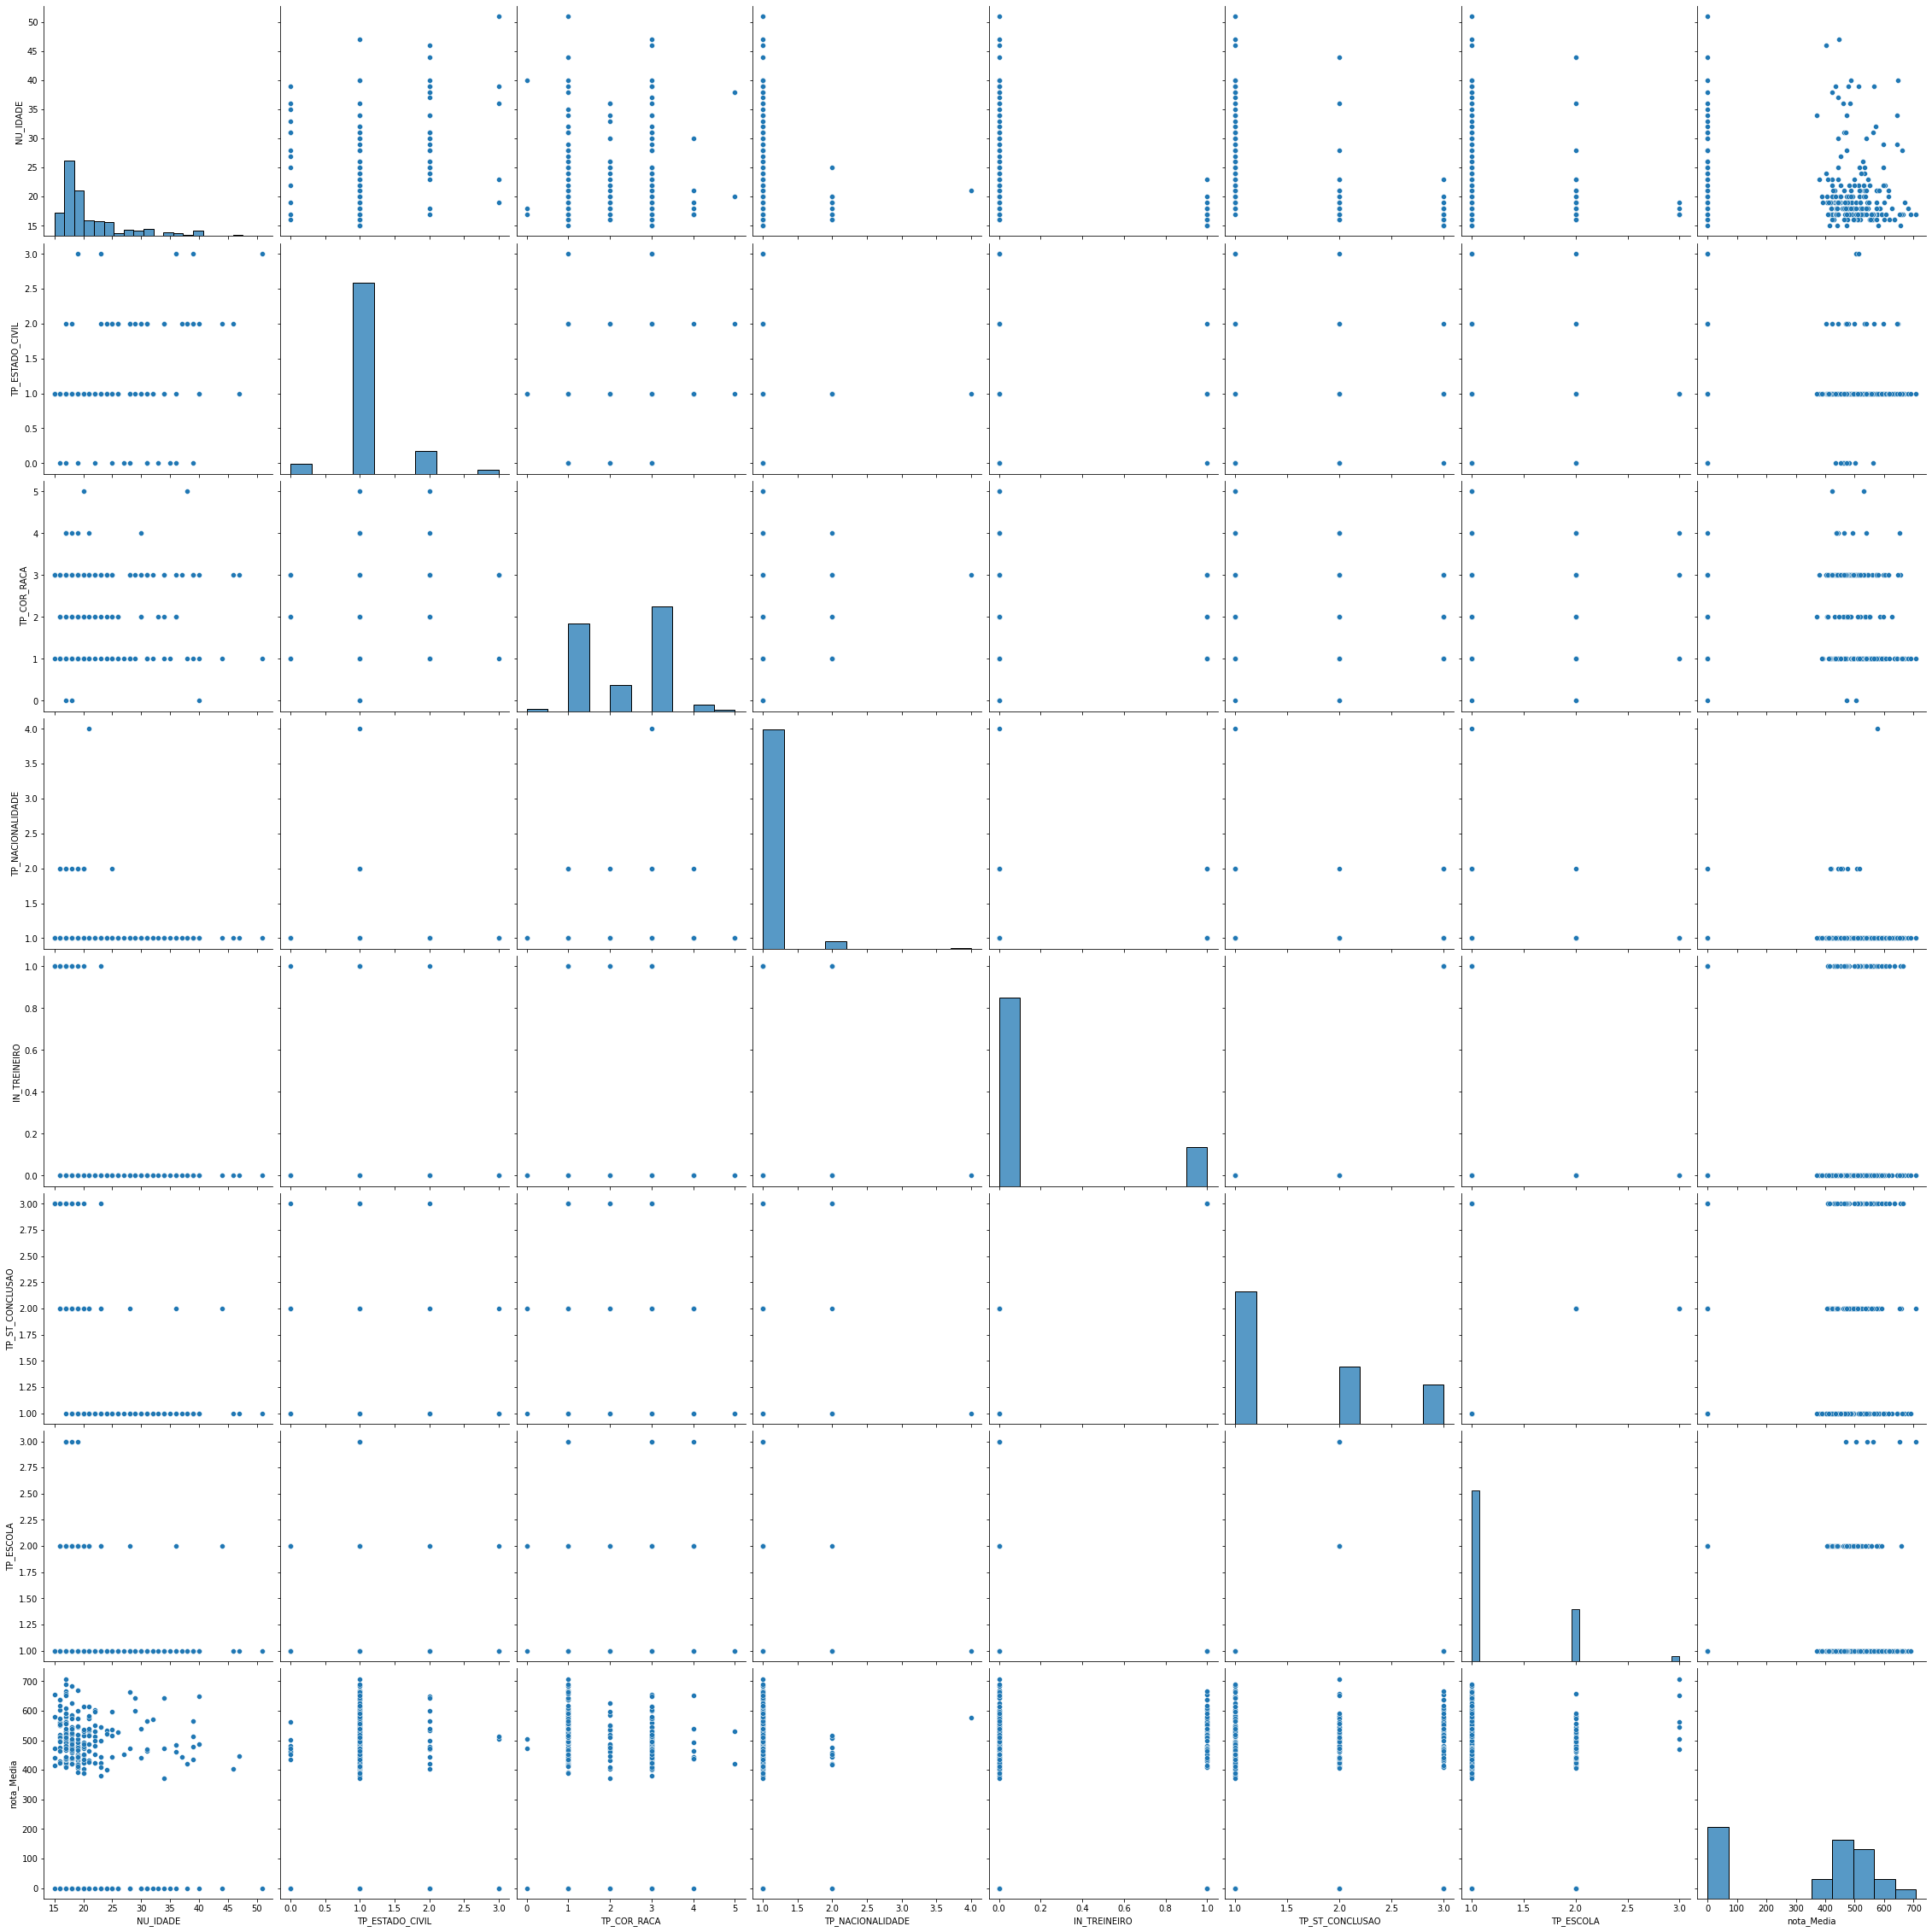

In [ ]:
sns.pairplot(data = df[['NU_IDADE', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'IN_TREINEIRO', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'nota_Media']], size=4,diag_kind="hist")

In [ ]:
#One hot
#Pairplot com barra

## Treino de modelo

### Regressão Linear

In [ ]:
# TODO: Testar várias combinações de variáveis e potências, multiplicações, etc.

In [ ]:
?LinearRegression

In [ ]:
# TODO: Testar normalizar e usar Ridge e Lasso

In [ ]:
A = train[train.columns[train.columns.str.startswith('IN_SALA_ESPECIAL')]]

In [ ]:
print(A)

In [ ]:
b = 0
for i in train.columns:
  if i.isdecimal():
    b = i

In [ ]:
print(i)